In [1]:
# ==========================================
# GCN IMPLEMENTATION (COMPLETE)
# ==========================================


In [2]:

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import networkx as nx


In [3]:

# ------------------------------------------
# 1. Graph Data
# ------------------------------------------
X = torch.rand((6, 10))

adj = torch.tensor([
    [1,1,0,0,0,0],
    [1,1,1,0,0,0],
    [0,1,1,1,0,0],
    [0,0,1,1,1,0],
    [0,0,0,1,1,1],
    [0,0,0,0,1,1]
], dtype=torch.float32)

labels = torch.tensor([0,1,0,1,0,1])


In [4]:

# ------------------------------------------
# 2. Model
# ------------------------------------------
class GCN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(10, 8)
        self.fc2 = nn.Linear(8, 2)

    def forward(self, x, adj):
        x = torch.matmul(adj, x)
        x = torch.relu(self.fc1(x))
        x = torch.matmul(adj, x)
        x = self.fc2(x)
        return x

model = GCN()
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()

losses = []


In [5]:

# ------------------------------------------
# 3. Training
# ------------------------------------------
for epoch in range(100):
    optimizer.zero_grad()
    output = model(X, adj)
    loss = loss_fn(output, labels)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())


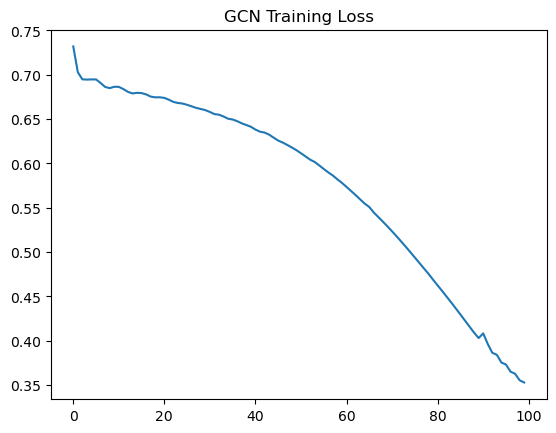

In [6]:

# ------------------------------------------
# 4. Visualization
# ------------------------------------------
plt.figure()
plt.plot(losses)
plt.title("GCN Training Loss")
plt.show()


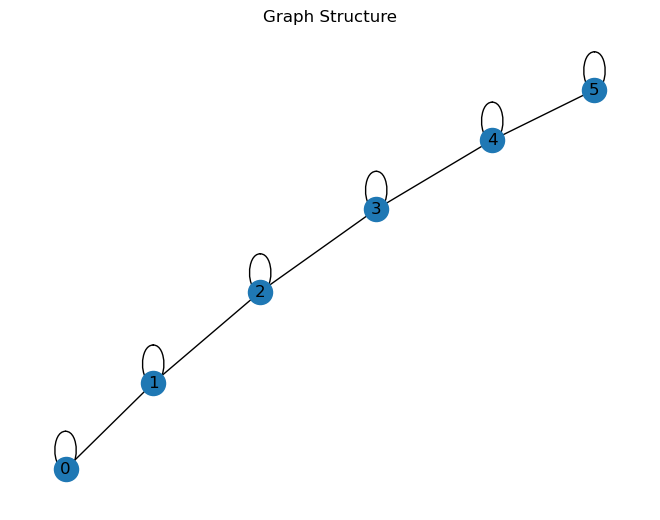

In [7]:

# Graph Visualization
G = nx.from_numpy_array(adj.numpy())

nx.draw(G, with_labels=True)
plt.title("Graph Structure")
plt.show()